<a href="https://colab.research.google.com/github/FatherNurt/FUNt-Cosmologiical-Model-of-All-Things/blob/main/C8_Companion_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# C8 Companion Notebook
**Geometric Regime Dynamics and Attractor Behavior**

**DOI:** 10.5281/zenodo.20689922  
**Author:** Michael K. Nowlin  
**License:** CC0 1.0 Universal

This notebook provides executable demonstrations of key concepts from C8, including phase attractor convergence, strain/coherence evolution, geometric ledger tracking, and the importance of log-scale visibility.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 11

print("Libraries loaded.")

Libraries loaded.


## 1. Phase Attractor Convergence (Fibonacci)

Demonstrates geometric attractor behavior from C8 Sections 3 and 9.

We compute Fibonacci ratios, project them into cyclic phase space, and observe convergence to a stable geometric phase near 222.49°.

In [2]:
def fib_ratio(n):
    if n < 1:
        return None
    a, b = 1, 1
    for _ in range(n-1):
        a, b = b, a + b
    return b / a

def phase(r):
    return (r * 360) % 360

phi = (1 + np.sqrt(5)) / 2
target_phase = 222.49

rows = []
for n in range(1, 16):
    r = fib_ratio(n)
    ph = phase(r)
    err_r = abs(r - phi)
    err_ph = min(abs(ph - target_phase), 360 - abs(ph - target_phase))
    rows.append({
        'n': n,
        'R_n': round(r, 6),
        'Error_vs_phi': round(err_r, 6),
        'Phase_deg': round(ph, 2),
        'Phase_Error_deg': round(err_ph, 2)
    })

df = pd.DataFrame(rows)
df

,n,R_n,Error_vs_phi,Phase_deg,Phase_Error_deg
0,1,1.000000,0.618034,0.00,137.51
1,2,2.000000,0.381966,0.00,137.51
2,3,1.500000,0.118034,180.00,42.49
3,4,1.666667,0.048633,240.00,17.51
4,5,1.600000,0.018034,216.00,6.49
5,6,1.625000,0.006966,225.00,2.51
6,7,1.615385,0.002649,221.54,0.95
7,8,1.619048,0.001014,222.86,0.37
8,9,1.617647,0.000387,222.35,0.14
9,10,1.618182,0.000148,222.55,0.06


### Phase Error Decay (Log Scale)

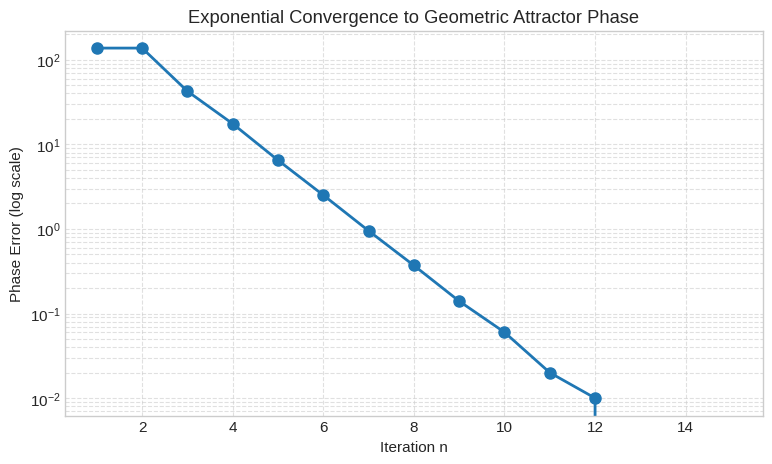

In [3]:
plt.figure()
plt.plot(df['n'], df['Phase_Error_deg'], marker='o', linewidth=2, markersize=8)
plt.yscale('log')
plt.xlabel('Iteration n')
plt.ylabel('Phase Error (log scale)')
plt.title('Exponential Convergence to Geometric Attractor Phase')
plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.show()

**Key observation:** On logarithmic scale the error decay is nearly linear — signature of geometric (exponential) convergence to the attractor.

## 2. Strain and Coherence Evolution

Simple simulation showing strain decreasing and coherence increasing as the system approaches a geometric attractor (C8 Section 4).

In [4]:
np.random.seed(42)
steps = 20
strain = np.zeros(steps)
coherence = np.zeros(steps)

strain[0] = 0.82
coherence[0] = 0.38

for i in range(1, steps):
    strain[i] = max(0.02, strain[i-1] * 0.72 + np.random.normal(0, 0.015))
    coherence[i] = min(0.97, 1.0 - strain[i] + np.random.normal(0, 0.025))

evolution = pd.DataFrame({
    'Step': range(steps),
    'Strain': np.round(strain, 3),
    'Coherence': np.round(coherence, 3)
})
evolution

,Step,Strain,Coherence
0,0,0.820,0.380
1,1,0.598,0.399
2,2,0.440,0.598
3,3,0.313,0.681
4,4,0.249,0.770
5,5,0.172,0.841
6,6,0.117,0.871
7,7,0.088,0.864
8,8,0.038,0.948
9,9,0.020,0.970


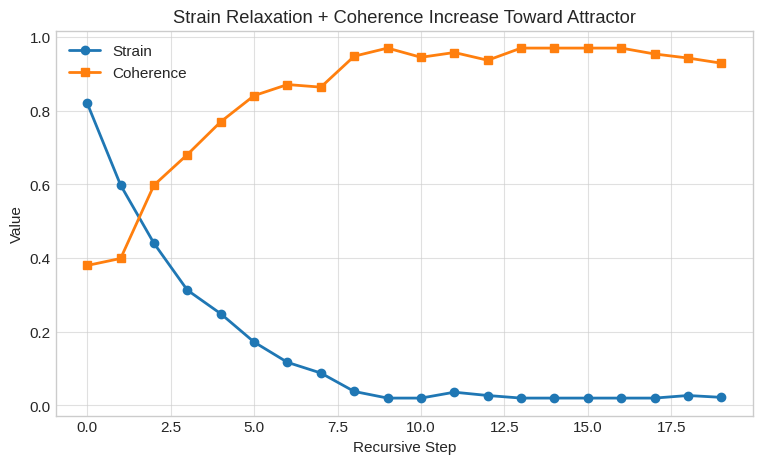

In [5]:
plt.figure()
plt.plot(evolution['Step'], evolution['Strain'], label='Strain', marker='o', linewidth=2)
plt.plot(evolution['Step'], evolution['Coherence'], label='Coherence', marker='s', linewidth=2)
plt.xlabel('Recursive Step')
plt.ylabel('Value')
plt.title('Strain Relaxation + Coherence Increase Toward Attractor')
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()

## 3. Geometric Ledger Example

Demonstrates the geometric ledger from C8 Section 7.

Tracking attractor proximity, strain, coherence, and effective scaling across a regime transition reveals geometric reorganization that simple labels miss.

In [6]:
ledger = pd.DataFrame([
    {'Step': 1, 'Regime': 'A', 'Attractor_Proximity': 0.12, 'Strain': 'High', 'Coherence': 0.71, 'Eff_D': 2.8},
    {'Step': 2, 'Regime': 'A', 'Attractor_Proximity': 0.05, 'Strain': 'Medium', 'Coherence': 0.84, 'Eff_D': 2.4},
    {'Step': 3, 'Regime': 'Transition', 'Attractor_Proximity': 0.18, 'Strain': 'High', 'Coherence': 0.62, 'Eff_D': 1.9},
    {'Step': 4, 'Regime': 'B', 'Attractor_Proximity': 0.07, 'Strain': 'Medium', 'Coherence': 0.79, 'Eff_D': 1.3},
    {'Step': 5, 'Regime': 'B', 'Attractor_Proximity': 0.02, 'Strain': 'Low', 'Coherence': 0.91, 'Eff_D': 1.2},
])
ledger

,Step,Regime,Attractor_Proximity,Strain,Coherence,Eff_D
0,1,A,0.12,High,0.71,2.8
1,2,A,0.05,Medium,0.84,2.4
2,3,Transition,0.18,High,0.62,1.9
3,4,B,0.07,Medium,0.79,1.3
4,5,B,0.02,Low,0.91,1.2


**Insight:** At Step 3 strain rises and coherence drops even though the label is only "Transition". The geometric ledger makes this reorganization visible.

## 4. Linear vs Log-Log Scale Visibility

Demonstrates why log-scale representation is a geometric requirement (C8 Section 6).

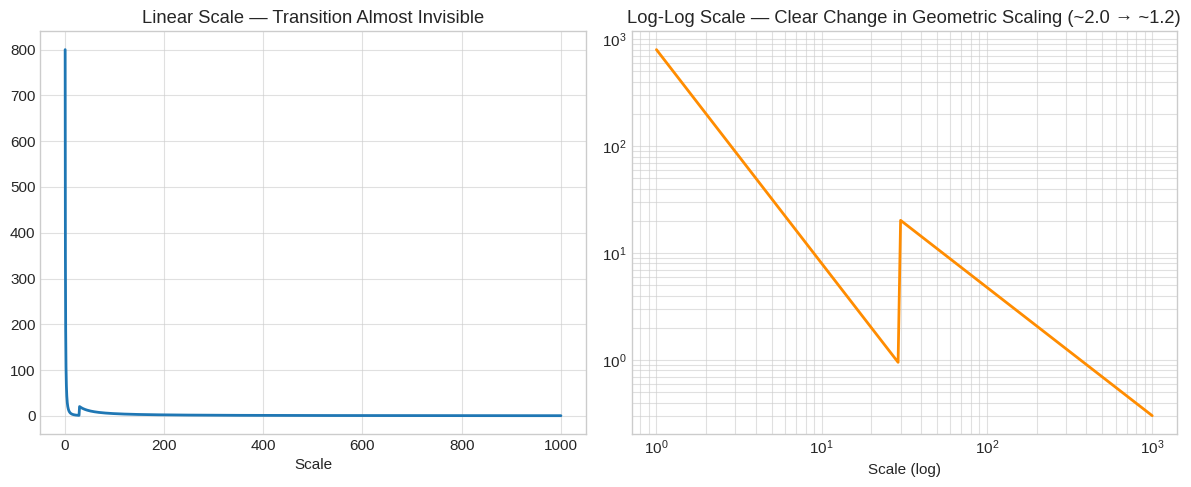

In [7]:
r = np.logspace(0, 3, 200)
f = np.where(r < 30, 800 / r**2.0, 1200 / r**1.2)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(r, f, linewidth=2)
ax[0].set_title('Linear Scale — Transition Almost Invisible')
ax[0].set_xlabel('Scale')
ax[0].grid(True, alpha=0.6)

ax[1].loglog(r, f, linewidth=2, color='darkorange')
ax[1].set_title('Log-Log Scale — Clear Change in Geometric Scaling (~2.0 → ~1.2)')
ax[1].set_xlabel('Scale (log)')
ax[1].grid(True, which='both', alpha=0.6)

plt.tight_layout()
plt.show()

**Conclusion:** The change in effective geometric scaling is nearly invisible on linear axes but immediately obvious on log-log axes. This is why C8 treats log-scale visibility as a geometric necessity.

## Summary

This notebook demonstrates the core geometric ideas from C8:

- Attractors as stable geometric phases
- Strain and coherence as coupled dynamic indicators
- Geometric ledger for tracking reorganization
- Log-scale visibility as essential for multi-scale geometric analysis

These support the shift toward geometry-first regime analysis.

**Next:** C9 will develop multi-scale geometric closure principles.

---

*CC0 1.0 Universal — DOI: 10.5281/zenodo.20689922*